# 🤖 LangGraph Examples - 3: A Conditional Graph

**Author:** *José Ignacio Orlando, PhD*

In this third example, we're going to learn how to structure a conditional graph in LangGraph, still with no LLMs involved. 

Our goal with this example is to learn how to structure a graph with conditional nodes, that will execute a specific path or another based on the agent state.

For this example, we're going to try a more "realistic" use case scenario, modeling in this case a mocked order fulfillment system. This system needs to track information about products, inventory levels, order quantities, and the actions taken. 

## Step 1 - Define the agent state

As in all our previous examples, the state will serve as our shared memory, allowing different nodes in the graph to access and update information about orders and inventory.

We'll define an ```OrderState``` that inherits from `TypedDict` and includes all the necessary fields to track an order through our fulfillment process. Notice that we're using `total=False` as in the second example, to make all fields optional, which gives us flexibility in how we initialize the state.

In [ ]:
from typing import TypedDict, List, Literal

class OrderState(TypedDict, total=False):
    product: str    # the name of the product
    inventory: int  # the current inventory level
    quantity: int   # the quantity requested in the order
    action: Literal["fulfilled", "backorder"] # the action taken
    backordered: int # the number of items backordered
    logs: List[str] # a list of logs to track the order fulfillment process


## Step 2.a - Define the (standard) nodes

Now we'll define the standard nodes that perform the actual work in our order fulfillment system. These nodes follow the same pattern we learned in the previous examples: they receive the current state, perform their operations, and return the updated state.

We have three standard nodes:
- `fulfill_order`: This node processes orders when we have sufficient inventory
- `create_backorder`: This node handles cases where we don't have enough inventory
- `check_inventory`: This is a **utility node** that logs inventory information (it's essentially a "no-op" node that just records what's happening)

Each node includes proper docstrings explaining their behavior and logs their actions for debugging and tracking purposes.

In [ ]:
# node function to model the process of fulfilling an order
def fulfill_order(state: OrderState) -> OrderState:
    """Fulfill the order and decrement inventory."""
    # decrement the inventory based on the requested amount
    state["inventory"] -= state["quantity"]
    # register that the action was a fulfillment
    state["action"] = "fulfilled"
    # leave a more detailed log of the action in the log
    state["logs"].append(
        f"[fulfill_order] fulfilled {state['quantity']} of {state['product']}. inventory now {state['inventory']}"
    )
    return state

# node function to model the process of creating a backorder
def create_backorder(state: OrderState) -> OrderState:
    """Create a backorder for the deficit."""
    # calculate the deficit, ensuring it's not negative
    deficit = max(0, state["quantity"] - state["inventory"])
    # update the backordered amount
    state["backordered"] = deficit
    # register that the action was a backorder
    state["action"] = "backorder"
    # leave a more detailed log of the action in the log
    state["logs"].append(
        f"[create_backorder] could not fulfill {state['quantity']} of {state['product']}. "
        f"inventory={state['inventory']}, backordered={deficit}"
    )
    return state

# node function to model the process of checking the inventory
def check_inventory(state: OrderState) -> OrderState:
    """No-op node used as the branching point. Keeps the pattern explicit."""
    # just a log to track the inventory
    state["logs"].append(
        f"[check_inventory] product={state['product']} inventory={state['inventory']} qty={state['quantity']}"
    )
    return state

## Step 2.b - Define the conditional node

This is where things get interesting. A conditional node is a special type of node that doesn't modify the state directly. Instead, it examines the current state and decides which path the execution should take next.

Our conditional node `route_by_availability` looks at the inventory level versus the requested quantity and returns the name of the next node to execute. This is the key to creating branching logic in our graph - the conditional node acts as a decision point that determines the execution path.

Notice that the conditional node returns a `Literal` type, which ensures type safety and makes it clear which nodes can be reached from this decision point.

In [ ]:
# conditional node to route the execution based on inventory availability
def route_by_availability(state: OrderState) -> Literal["fulfill_order", "create_backorder"]:
    """Return the next node key based on inventory vs requested quantity."""
    # check if we have enough inventory to fulfill the order
    if state["inventory"] >= state["quantity"]:
        # if so, route to the fulfill_order node
        return "fulfill_order"
    else:
        # otherwise, route to the create_backorder node
        return "create_backorder"


## Step 3 - Define the execution graph

Now we'll put everything together to create our conditional execution graph. This is more complex than our previous sequential graph because we need to handle branching logic.

The key differences from our previous example are:
1. We add multiple nodes instead of just one
2. We use`add_conditional_edges()` instead of simple edges to create branching paths
3. We explicitly define `START` and `END` connections to show the complete flow

The `add_conditional_edges()` method takes three parameters:
* The name of the source node (where the decision is made)
* The conditional function that is used to choose where to move next (our routing logic)
* A mapping of possible return values to target nodes

This creates a graph where execution can follow different paths based on the state, making our system much more flexible and realistic.

In [8]:
from langgraph.graph import StateGraph, START, END

# initialize a state graph with the OrderState type
graph = StateGraph(OrderState)

# add the nodes to the graph
graph.add_node("fulfill_order", fulfill_order)
graph.add_node("create_backorder", create_backorder)
graph.add_node("router", lambda state: state) # this is a utility node that just returns the state

# add the start edge to the graph
graph.add_edge(START, "router")
# add the conditional edges to the graph
graph.add_conditional_edges(
    "router", # name of the source node
    route_by_availability, # conditional function
    {
        "fulfill_order": "fulfill_order", # mapping of possible return values to target nodes
        "create_backorder": "create_backorder",
    },
)
# add the end edges to the graph
graph.add_edge("fulfill_order", END)
graph.add_edge("create_backorder", END)

# compile the graph
app = graph.compile()

As usual, let's visualize the graph to double check if everything went well:

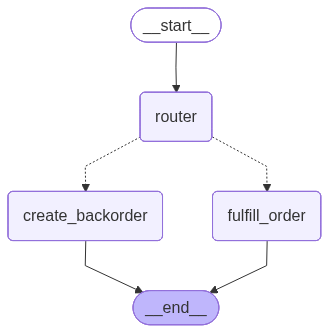

In [9]:
from IPython.display import Image, display
# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Step 4 - Execute!

Now let's test our conditional graph with different scenarios! We'll run two examples: one where we have sufficient inventory (which should trigger the fulfillment path) and another where we don't have enough inventory (which should trigger the backorder path).

The execution will show us how the graph makes decisions and follows different paths based on the input state. Notice how the logs will help us trace exactly what happened during each execution, making it easy to understand the decision-making process.

This demonstrates the power of conditional graphs - they can handle complex business logic by making intelligent decisions based on the current state, just like a real agent would (once we plug a brain into this).

In [12]:
examples: List[OrderState] = [
        {"product": "Widget", "inventory": 10, "quantity": 4, "logs": []},  # should fulfill
        {"product": "Gizmo", "inventory": 2, "quantity": 5, "logs": []},    # should backorder
    ]

for i, state in enumerate(examples, start=1):
    print(f"\n=== Run #{i} ===")
    final = app.invoke(state)
    print("Final state:", final)
    print("Logs:")
    for line in final["logs"]:
        print(" ", line)


=== Run #1 ===
Final state: {'product': 'Widget', 'inventory': 6, 'quantity': 4, 'action': 'fulfilled', 'logs': ['[fulfill_order] fulfilled 4 of Widget. inventory now 6']}
Logs:
  [fulfill_order] fulfilled 4 of Widget. inventory now 6

=== Run #2 ===
Final state: {'product': 'Gizmo', 'inventory': 2, 'quantity': 5, 'action': 'backorder', 'backordered': 3, 'logs': ['[create_backorder] could not fulfill 5 of Gizmo. inventory=2, backordered=3']}
Logs:
  [create_backorder] could not fulfill 5 of Gizmo. inventory=2, backordered=3
